In [2]:
from pyspoc import Calculator, Config

my_config_dict = {
    'ReducedStatistics': {
        'GPLVM_R2.py': {
            'GPLVM_r2': {
                'schemes': {
                    'scheme_1': {
                        'ARD_initial_dimension': 10,
                        'max_iters': 200
                    }
                }
            }
        },
        'GPLVM_Beta.py': {
            'GPLVM_beta': {
                'schemes': {
                    'scheme_1': {
                        'ARD_initial_dimension': 10,
                        'max_iters': 200
                    }
                }
            }
        },
        'GPLVM_DoF.py': {
            'GPLVM_dof': {
                'schemes': {
                    'scheme_1': {
                        'ARD_initial_dimension': 10,
                        'max_iters': 200
                    }
                }
            }
        },
        'GPyTorch_BayesianGPLVM_R2.py': {
            'GPyTorch_BayesianGPLVM_R2': {
                'schemes': {
                    'scheme_1': {
                        'ARD_initial_dimension': 10,
                        'max_iters': 200
                    }
                }
            }
        },
        'GPyTorch_BayesianGPLVM_Beta.py': {
            'GPyTorch_BayesianGPLVM_Beta': {
                'schemes': {
                    'scheme_1': {
                        'ARD_initial_dimension': 10,
                        'max_iters': 200
                    }
                }
            }
        },
        'GPyTorch_BayesianGPLVM_Dim3.py': {
            'GPyTorch_BayesianGPLVM_Dim3': {
                'schemes': {
                    'scheme_1': {
                        'ARD_initial_dimension': 10,
                        'max_iters': 200
                    }
                }
            }
        }
    }
}

cfg = Config.from_dict("auto_cfg", my_config_dict)

Octave not available: No module named 'oct2py'
Jpype JVM not available: No module named 'jpype'
Registering configuration dictionary object.
Building internal configuration.
GPLVM_R2.py
    ✔ ReducedStatistic GPLVM_r2 scheme 'scheme_1' added successfully.
GPLVM_Beta.py
    ✔ ReducedStatistic GPLVM_beta scheme 'scheme_1' added successfully.
GPLVM_DoF.py
    ✔ ReducedStatistic GPLVM_dof scheme 'scheme_1' added successfully.
GPyTorch_BayesianGPLVM_R2.py
    ✔ ReducedStatistic GPyTorch_BayesianGPLVM_R2 scheme 'scheme_1' added successfully.
GPyTorch_BayesianGPLVM_Beta.py
    ✔ ReducedStatistic GPyTorch_BayesianGPLVM_Beta scheme 'scheme_1' added successfully.
GPyTorch_BayesianGPLVM_Dim3.py
    ✔ ReducedStatistic GPyTorch_BayesianGPLVM_Dim3 scheme 'scheme_1' added successfully.


In [129]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.linalg import cholesky, block_diag
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_swiss_roll, make_s_curve


# generate noise for each dataset
def add_noise(Y: np.ndarray, sigma: float, rng=None) -> np.ndarray:
    if rng is None:
        rng = np.random.default_rng()
    return Y + sigma * rng.normal(size=Y.shape)



def run_all_and_store_results(datasets: dict, cfg):
    """
    datasets: dict[name -> np.ndarray of shape (1000,100)]
    cfg: py-spoc Config
    """
    all_results = {}
    names = list(datasets.keys())  

    for i, name in enumerate(names, 1):
        X = datasets[name]


        calc = Calculator(X)
        calc.compute(cfg)

        all_results[name] = calc.results
        print(f"[{i:02d}/{len(names)}] done: {name}")

    return all_results



# 1. Smooth manifold generator: Swiss Roll, S-Curve, Helicoid, Sphere, Intersecting Planes
class SyntheticDataGenerator:
    def __init__(self, n_samples=1000, n_features=100, seed=42):
        self.n = n_samples
        self.p = n_features
        self.rng = np.random.default_rng(seed)
        self.datasets = {}
        self.meta = {}

    def _project_to_high_dim(self, X_low):
        d = X_low.shape[1]
        Q, _ = np.linalg.qr(self.rng.normal(size=(self.p, d)))
        X_high = X_low @ Q.T
        return StandardScaler().fit_transform(X_high)

    def add_noise(self, X_clean, noise_level=0.1):
        return X_clean + self.rng.normal(size=X_clean.shape) * noise_level

    def generate_all(self, noise_level=0.1):
        # 1) Swiss Roll, intrinsic dim = 2
        X_low, _ = make_swiss_roll(n_samples=self.n, noise=0.0, random_state=123)
        X = self.add_noise(self._project_to_high_dim(X_low), noise_level)
        self.datasets["Swiss Roll"] = X
        self.meta["Swiss Roll"] = {"family": "manifold", "true_dim": 2, "noise": noise_level}

        # 2) S-Curve, intrinsic dim = 2
        X_low, _ = make_s_curve(n_samples=self.n, noise=0.0, random_state=456)
        X = self.add_noise(self._project_to_high_dim(X_low), noise_level)
        self.datasets["S-Curve"] = X
        self.meta["S-Curve"] = {"family": "manifold", "true_dim": 2, "noise": noise_level}

        # 3) Helicoid, intrinsic dim = 2
        m1 = int(np.sqrt(self.n))
        m2 = int(np.ceil(self.n / m1))
        t = np.linspace(0, 4 * np.pi, m1)
        r = np.linspace(0.6, 1.4, m2)
        T, R = np.meshgrid(t, r)
        T = T.ravel()[:self.n]
        R = R.ravel()[:self.n]

        x = R * np.cos(T)
        y = R * np.sin(T)
        z = 0.1 * T
        X_low = np.stack([x, y, z], axis=1)

        X = self.add_noise(self._project_to_high_dim(X_low), noise_level)
        self.datasets["Helicoid"] = X
        self.meta["Helicoid"] = {"family": "manifold", "true_dim": 2, "noise": noise_level}

        # 4) Sphere, intrinsic dim = 2
        u = self.rng.random(self.n)
        v = self.rng.random(self.n)
        theta = 2 * np.pi * u
        phi = np.arccos(2 * v - 1)
        x = np.sin(phi) * np.cos(theta)
        y = np.sin(phi) * np.sin(theta)
        z = np.cos(phi)
        X_low = np.stack([x, y, z], axis=1)

        X = self.add_noise(self._project_to_high_dim(X_low), noise_level)
        self.datasets["Sphere"] = X
        self.meta["Sphere"] = {"family": "manifold", "true_dim": 2, "noise": noise_level}

        # 5) Intersecting Planes, intrinsic dim = 2
        n1 = self.n // 2
        n2 = self.n - n1
        d1 = self.rng.normal(size=(n1, 2))
        X1 = np.hstack([d1, np.zeros((n1, 1))])
        d2 = self.rng.normal(size=(n2, 2))
        X2 = np.hstack([np.zeros((n2, 1)), d2])
        X_low = np.vstack([X1, X2])

        X = self.add_noise(self._project_to_high_dim(X_low), noise_level)
        self.datasets["Intersecting Planes"] = X
        self.meta["Intersecting Planes"] = {"family": "manifold", "true_dim": 2, "noise": noise_level}

        return self.datasets, self.meta



# 2. Gaussian process latent generator:latent_i
def latent_circle(n: int, rng: np.random.Generator) -> np.ndarray:
    theta = 2 * np.pi * rng.random(n)
    Z = np.column_stack([np.cos(theta), np.sin(theta)])
    return Z


def lmm_generate(
    Z: np.ndarray,
    p: int,
    sigma: float,
    rng: np.random.Generator,
    kernel: str = "rbf",
    alpha: float = 1.0,
    gamma: float = 1.0,
    eps: float = 1e-8,
) -> np.ndarray:
    n = Z.shape[0]

    if kernel == "rbf":
        sq = squareform(pdist(Z, metric="sqeuclidean"))
        K = alpha * np.exp(-0.5 * gamma * sq)
    elif kernel == "poly2":
        G = Z @ Z.T
        K = (G + 1.0) ** 2
    elif kernel == "random":
        A = rng.normal(size=(n, n))
        K = A @ A.T
    else:
        raise ValueError("kernel must be one of {'rbf','poly2','random'}")

    K = K + np.eye(n) * eps
    L = cholesky(K, lower=True)

    W = rng.normal(size=(n, p))
    X_signal = L @ W

    if sigma > 0:
        X_noise = sigma * rng.normal(size=(n, p))
        Y = X_signal + X_noise
    else:
        Y = X_signal

    return Y.astype(np.float64, copy=False)


def stretch_latent_circle(Z: np.ndarray, sx: float = 1.0, sy: float = 1.0) -> np.ndarray:
    if Z.shape[1] != 2:
        raise ValueError("stretch_latent_circle expects Z with shape (n, 2).")

    S = np.array([[sx, 0.0], [0.0, sy]])
    return Z @ S.T


def generate_latent_group(
    n_samples: int = 1000,
    n_features: int = 100,
    sigma: float = 0.1,
    kernel: str = "rbf",
    alpha: float = 1.0,
    gamma: float = 1.0,
    latent_seed: int = 42,
    obs_seed: int = 999,
):
    rng_latent = np.random.default_rng(latent_seed)
    Z_base = latent_circle(n_samples, rng_latent)

    stretch_specs = [
        (1.06, 0.91),
        (1.05, 0.95),
        (1.10, 0.90),
        (1.08, 1.00),
        (1.00, 0.92),
    ]

    datasets = {}
    meta = {}

    for i, (sx, sy) in enumerate(stretch_specs, start=1):
        Z_use = stretch_latent_circle(Z_base, sx=sx, sy=sy)
        rng_obs = np.random.default_rng(obs_seed)

        Y = lmm_generate(
            Z=Z_use,
            p=n_features,
            sigma=sigma,
            rng=rng_obs,
            kernel=kernel,
            alpha=alpha,
            gamma=gamma,
        )

        name = f"latent_{i}"
        datasets[name] = Y
        meta[name] = {
            "family": "lmm_latent",
            "sigma": sigma,
            "kernel": kernel,
            "stretch": (sx, sy),
        }

    return datasets, meta



# 3. sparse generator: sparse_i
def sparse_factor_model(
    n: int,
    p: int,
    q_true: int,
    sigma: float,
    sparsity: float = 0.9,
    rng=None
) -> np.ndarray:
    if rng is None:
        rng = np.random.default_rng()

    Z = rng.normal(size=(n, q_true))
    A = rng.normal(size=(p, q_true)) / np.sqrt(q_true)

    mask = rng.random(size=A.shape) > sparsity
    A = A * mask

    for j in range(q_true):
        if np.all(A[:, j] == 0):
            idx = rng.integers(0, p)
            A[idx, j] = rng.normal()

    Y = Z @ A.T
    Y = add_noise(Y, sigma, rng)
    return Y.astype(np.float64, copy=False)


def generate_sparse_group(n=1000, p=100, seed=42):
    rng = np.random.default_rng(seed)
    datasets = {}
    meta = {}

    sparsity_list = [0.82, 0.84, 0.86, 0.88, 0.90]

    for i, s in enumerate(sparsity_list, start=1):
        Y = sparse_factor_model(
            n=n,
            p=p,
            q_true=1,
            sigma=0.01,
            sparsity=s,
            rng=rng
        )
        name = f"sparse_{i}"
        datasets[name] = Y
        meta[name] = {
            "family": "sparse_factor",
            "true_dim": 1,
            "noise": 0.01,
            "sparsity": s,
        }

    return datasets, meta



# 4. Linear low-rank generator: linear_i
def linear_low_rank(n: int, p: int, q_true: int, sigma: float, rng=None) -> np.ndarray:
    if rng is None:
        rng = np.random.default_rng()
    Z = rng.normal(size=(n, q_true))
    A = rng.normal(size=(p, q_true)) / np.sqrt(q_true)
    Y = Z @ A.T
    Y = add_noise(Y, sigma, rng)
    return Y.astype(np.float64, copy=False)


def generate_linear_group(n=1000, p=100, seed=52):
    datasets = {}
    meta = {}

    q_true = 1
    sigma = 0.01

    for i in range(1, 6):
        rng = np.random.default_rng(seed + i)

        Y = linear_low_rank(
            n=n,
            p=p,
            q_true=q_true,
            sigma=sigma,
            rng=rng
        )

        name = f"linear_{i}"
        datasets[name] = Y
        meta[name] = {
            "family": "linear_low_rank",
            "true_dim": q_true,
            "noise": sigma,
            "seed": seed + i,
        }

    return datasets, meta



# 5. Block covariance generator
def make_block_covariance_matrix(
    p: int,
    n_blocks: int,
    rho_within: float = 0.75,
    rho_between: float = 0.00
) -> np.ndarray:
    if not (0.0 <= rho_between <= rho_within < 1.0):
        raise ValueError("Need 0 <= rho_between <= rho_within < 1")

    block_sizes = np.full(n_blocks, p // n_blocks, dtype=int)
    block_sizes[: p % n_blocks] += 1

    blocks = []
    for b in block_sizes:
        B = (1.0 - rho_within) * np.eye(b) + rho_within * np.ones((b, b))
        blocks.append(B)

    Sigma = block_diag(*blocks)

    if rho_between > 0:
        Sigma = Sigma + rho_between * (np.ones((p, p)) - np.eye(p))
        np.fill_diagonal(Sigma, 1.0)

    Sigma = 0.5 * (Sigma + Sigma.T)
    Sigma = Sigma + 1e-8 * np.eye(p)
    return Sigma


def block_covariance_dataset(
    n: int,
    p: int,
    n_blocks: int,
    sigma: float = 0.30,
    rho_within: float = 0.75,
    rho_between: float = 0.00,
    rng=None
):
    if rng is None:
        rng = np.random.default_rng()

    Sigma = make_block_covariance_matrix(
        p=p,
        n_blocks=n_blocks,
        rho_within=rho_within,
        rho_between=rho_between
    )

    L = np.linalg.cholesky(Sigma)
    X = rng.normal(size=(n, p)) @ L.T

    if sigma > 0:
        X = X + sigma * rng.normal(size=(n, p))

    return X.astype(np.float64, copy=False), Sigma


def generate_block_group(n=1000, p=100, seed=123):
    rng = np.random.default_rng(seed)
    datasets = {}
    sigmas = {}
    meta = {}

    for i, k in enumerate([2, 3, 4, 5, 6], start=1):
        Y, Sigma = block_covariance_dataset(
            n=n,
            p=p,
            n_blocks=k,
            sigma=0.30,
            rho_within=0.75,
            rho_between=0.02,
            rng=rng
        )
        name = f"block_{i}"
        datasets[name] = Y
        sigmas[name] = Sigma
        meta[name] = {
            "family": "block_covariance",
            "n_blocks": k,
            "rho_within": 0.75,
            "rho_between": 0.02,
            "noise": 0.30,
            "n": n,
            "p": p,
            "manifold": False,
        }

    return datasets, sigmas, meta



# 6. Gaussian random noise generator: noise_i
def iid_gaussian(n: int, p: int, sigma: float, rng: np.random.Generator) -> np.ndarray:
    Y = rng.normal(size=(n, p))
    Y = add_noise(Y, sigma, rng)
    return Y.astype(np.float64, copy=False)


def generate_noise_group(n=1000, p=100, seed=777):
    rng = np.random.default_rng(seed)
    datasets = {}
    meta = {}

    sigma_list = [0.05, 0.10, 0.15, 0.20, 0.25]

    for i, s in enumerate(sigma_list, start=1):
        Y = iid_gaussian(n=n, p=p, sigma=s, rng=rng)
        name = f"noise_{i}"
        datasets[name] = Y
        meta[name] = {
            "family": "iid_gaussian_noise",
            "noise": s,
            "n": n,
            "p": p,
        }

    return datasets, meta



# 5 smooth manifold datasets
smooth_gen = SyntheticDataGenerator(n_samples=1000, n_features=100, seed=42)
smooth_datasets_5, smooth_meta_5 = smooth_gen.generate_all(noise_level=0.1)

# 5 gaussian process latent datasets
latent_datasets_5, latent_meta_5 = generate_latent_group(
    n_samples=1000,
    n_features=100,
    sigma=0.1,
    kernel="rbf",
    alpha=1.0,
    gamma=1.0,
    latent_seed=42,
    obs_seed=999,
)

# 5 sparse datasets
sparse_datasets_5, sparse_meta_5 = generate_sparse_group(n=1000, p=100, seed=42)

# 5 linear low-rank datasets
linear_datasets_5, linear_meta_5 = generate_linear_group(n=1000, p=100, seed=52)

# 5 block covariance datasets
block_datasets_5, block_sigmas_5, block_meta_5 = generate_block_group(n=1000, p=100, seed=123)

# 5 random noise
noise_datasets_5, noise_meta_5 = generate_noise_group(n=1000, p=100, seed=777)


# 30 datasets in total
all_datasets_30 = {}
all_meta_30 = {}

for ds, mt in [
    (smooth_datasets_5, smooth_meta_5),
    (latent_datasets_5, latent_meta_5),
    (sparse_datasets_5, sparse_meta_5),
    (linear_datasets_5, linear_meta_5),
    (block_datasets_5, block_meta_5),
    (noise_datasets_5, noise_meta_5),
]:
    all_datasets_30.update(ds)
    all_meta_30.update(mt)

assert len(all_datasets_30) == 30, f"Expected 30 datasets, got {len(all_datasets_30)}"


# check
print("Total number of datasets:", len(all_datasets_30))
for k in all_datasets_30.keys():
    print(k, all_datasets_30[k].shape)



Total number of datasets: 30
Swiss Roll (1000, 100)
S-Curve (1000, 100)
Helicoid (1000, 100)
Sphere (1000, 100)
Intersecting Planes (1000, 100)
latent_1 (1000, 100)
latent_2 (1000, 100)
latent_3 (1000, 100)
latent_4 (1000, 100)
latent_5 (1000, 100)
sparse_1 (1000, 100)
sparse_2 (1000, 100)
sparse_3 (1000, 100)
sparse_4 (1000, 100)
sparse_5 (1000, 100)
linear_1 (1000, 100)
linear_2 (1000, 100)
linear_3 (1000, 100)
linear_4 (1000, 100)
linear_5 (1000, 100)
block_1 (1000, 100)
block_2 (1000, 100)
block_3 (1000, 100)
block_4 (1000, 100)
block_5 (1000, 100)
noise_1 (1000, 100)
noise_2 (1000, 100)
noise_3 (1000, 100)
noise_4 (1000, 100)
noise_5 (1000, 100)


In [8]:
all_results_30 = run_all_and_store_results(
    all_datasets_30,
    cfg
)

Normalising the dataset using StandardScaler 



Processing [None: GPLVM_R2.py.GPLVM_r2.scheme_1]:   0%|   | 0/6 [00:00<?, ?it/s]

DEBUG: Starting optimization. Data shape: (1000, 100)


Processing [None: GPLVM_Beta.py.GPLVM_beta.scheme_1]:  17%|▏| 1/6 [00:06<00:32, 

DEBUG: Opt result: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH, Iters: 25, Loss: -72063.9536
DEBUG: Raw Diff: 4977952.80, Scaled Diff (by N): 49.78
DEBUG: Starting optimization for Beta. Data shape: (1000, 100)


...

DEBUG: Opt result: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH, Loss: 148479.8504
DEBUG: Estimated DoF: 10.9935 (Normalized: 0.0110)
DEBUG: Starting GPyTorch training. Data: (1000, 100)


Processing [None: GPyTorch_BayesianGPLVM_Beta.py.GPyTorch_BayesianGPLVM_Beta.sch

DEBUG: ELL_real: -141177.09, ELL_null: -142076.47
DEBUG: Real Noise Variance: 0.501732 (Beta: 1.99)
DEBUG: GPyTorch Pseudo R2: 0.006330


Processing [None: GPyTorch_BayesianGPLVM_Dim3.py.GPyTorch_BayesianGPLVM_Dim3.sch

DEBUG: PURE NOISE DETECTED (Model Collapsed). Forcing dimension to 10.
DEBUG: Mean Lengthscales: [3.93 3.95 3.95 3.95 3.98 3.97 3.98 4.   4.   4.02]
DEBUG: Latent Std: [0.001 0.002 0.001 0.002 0.002 0.001 0.001 0.001 0.001 0.001]
DEBUG: Contribution Ratio: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
DEBUG: Active Dimensions (Count): 10

Calculation complete. Time taken: 85.4085s
[30/30] done: noise_5


### This is the (30,6) py-spoc data matrix

In [94]:
results = pd.concat(all_results_30)
results

,Statistic,GPLVM_R2.py.GPLVM_r2.scheme_1,GPLVM_Beta.py.GPLVM_beta.scheme_1,GPLVM_DoF.py.GPLVM_dof.scheme_1,GPyTorch_BayesianGPLVM_R2.py.GPyTorch_BayesianGPLVM_R2.scheme_1,GPyTorch_BayesianGPLVM_Beta.py.GPyTorch_BayesianGPLVM_Beta.scheme_1,GPyTorch_BayesianGPLVM_Dim3.py.GPyTorch_BayesianGPLVM_Dim3.scheme_1
,Reducer,self,self,self,self,self,self
Swiss Roll,0,1.014689,115.734205,18.746942,1.009962,251.101452,3.0
S-Curve,0,1.012815,117.412903,20.945148,1.009792,199.342776,3.0
Helicoid,0,1.006077,121.945153,10.802928,1.010091,235.662725,2.0
Sphere,0,1.013525,114.547572,19.526130,1.010449,199.650977,3.0
Intersecting Planes,0,1.015113,117.478540,18.264884,1.010392,177.722907,3.0
latent_1,0,1.014288,37.640135,94.065484,1.010833,183.223967,2.0
latent_2,0,1.014260,31.984415,82.593215,1.010351,174.165885,2.0
latent_3,0,1.014176,31.426268,88.980672,1.010477,177.688717,2.0
latent_4,0,1.015051,40.353861,70.714164,1.011033,185.285281,3.0


Fulcher-normalised matrix shape: (30, 6)
Cut height for 6 clusters: 0.4845


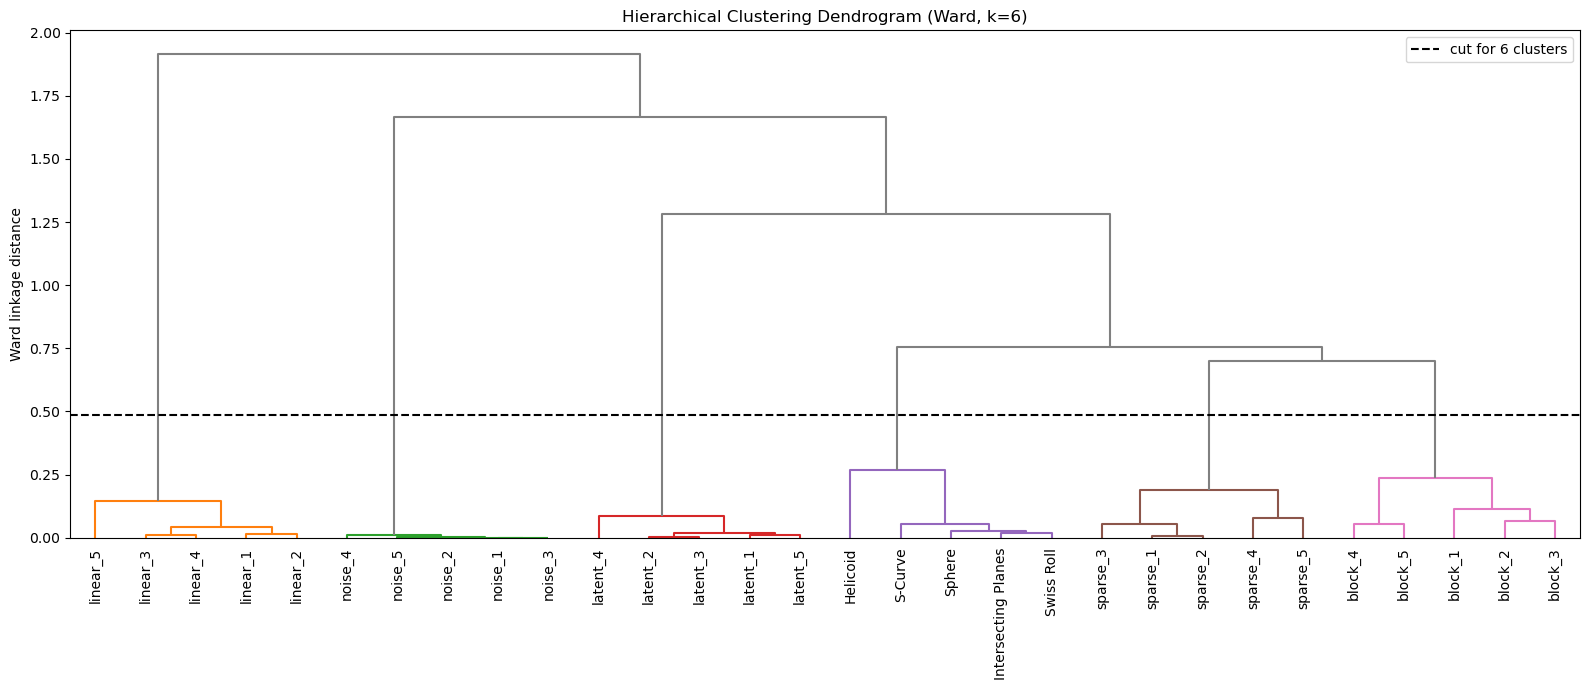

In [130]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.special import expit



# Fulcher-style robust sigmoidal normalisation
def fulcher_sigmoid_normalize(X_df, scale_factor=1.35, eps=1e-12):
    """
    Fulcher-style outlier-robust sigmoidal normalisation.

    For each feature/statistic column j:
        x_ij -> sigmoid((x_ij - median_j) / (scale_factor * IQR_j))

    This uses median and IQR instead of mean and standard deviation,
    making it more robust to extreme statistic values such as large beta.
    """
    X = X_df.copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(axis=0))

    X_values = X.to_numpy(dtype=float)

    med = np.median(X_values, axis=0)
    q75 = np.quantile(X_values, 0.75, axis=0)
    q25 = np.quantile(X_values, 0.25, axis=0)
    iqr = q75 - q25

    # If IQR is zero or extremely small, fall back to standard deviation
    std = np.std(X_values, axis=0)
    scale = scale_factor * iqr
    scale = np.where(scale > eps, scale, std)
    scale = np.where(scale > eps, scale, 1.0)

    X_norm = expit((X_values - med) / scale)

    X_norm_df = pd.DataFrame(
        X_norm,
        index=X.index,
        columns=X.columns
    )

    return X_norm_df



results = pd.concat(all_results_30)

if isinstance(results.index, pd.MultiIndex):
    results = results.copy()
    results.index = results.index.get_level_values(0)

X_df = results.groupby(level=0).mean(numeric_only=True)

if isinstance(X_df.columns, pd.MultiIndex):
    X_df.columns = [
        "__".join([str(x) for x in col if str(x) != ""])
        for col in X_df.columns.to_flat_index()
    ]





# get fulcher normalised matrix

X_fulcher = fulcher_sigmoid_normalize(X_df)


X_scaled = X_fulcher.values
print("Fulcher-normalised matrix shape:", X_fulcher.shape)



# Ward hierarchical clustering

Z = linkage(X_scaled, method="ward")

# cut to 6 classes
clusters = fcluster(Z, t=6, criterion="maxclust")

cluster_df = pd.DataFrame({
    "dataset": X_df.index,
    "cluster": clusters
}).sort_values(["cluster", "dataset"])




# compute height

n = X_df.shape[0]
k = 6

h1 = Z[n - k - 1, 2]

h2 = Z[n - k, 2] if (n - k) < Z.shape[0] else h1 + 1.0

cut_height = (h1 + h2) / 2.0

print(f"Cut height for {k} clusters: {cut_height:.4f}")



# draw dendrogram

plt.figure(figsize=(16, 7))

dendrogram(
    Z,
    labels=X_df.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=cut_height,
    above_threshold_color="gray",
)

plt.axhline(
    y=cut_height,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"cut for {k} clusters"
)

plt.title(f"Hierarchical Clustering Dendrogram (Ward, k={k})")
plt.ylabel("Ward linkage distance")
plt.legend()
plt.tight_layout()


plt.savefig("hierarchical_clustering_fulcher_normalised.pdf", format="pdf", bbox_inches="tight")

plt.show()

Dataset correlation matrix shape: (30, 30)


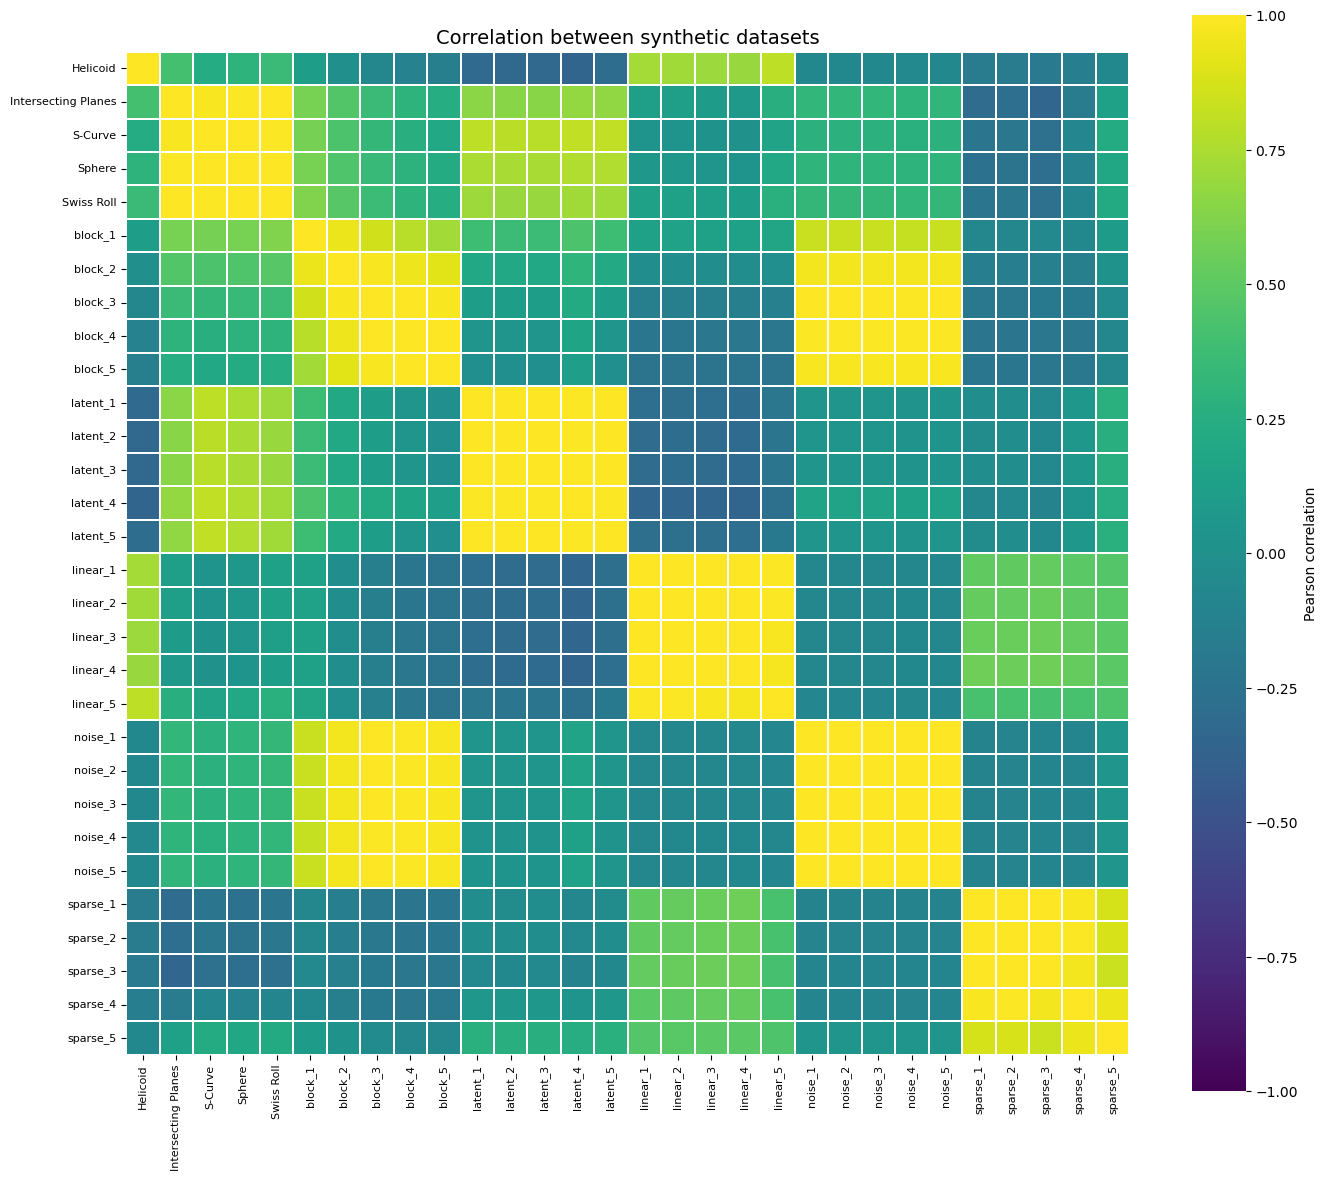

In [132]:
import seaborn as sns

X_heat = X_df.copy()

X_fulcher = fulcher_sigmoid_normalize(X_heat)

X_scaled_df = pd.DataFrame(
    X_fulcher.values,
    index=X_heat.index,
    columns=X_heat.columns
)


# calculate correlations between datasets
dataset_corr = X_scaled_df.T.corr(method="pearson")

print("Dataset correlation matrix shape:", dataset_corr.shape)


# draw heatmap
plt.figure(figsize=(14, 12))

sns.heatmap(
    dataset_corr,
    cmap="viridis",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Pearson correlation"}
)

plt.title(
    "Correlation between synthetic datasets",
    fontsize=14
)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()

plt.savefig(
    "dataset_correlation_heatmap_fulcher.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

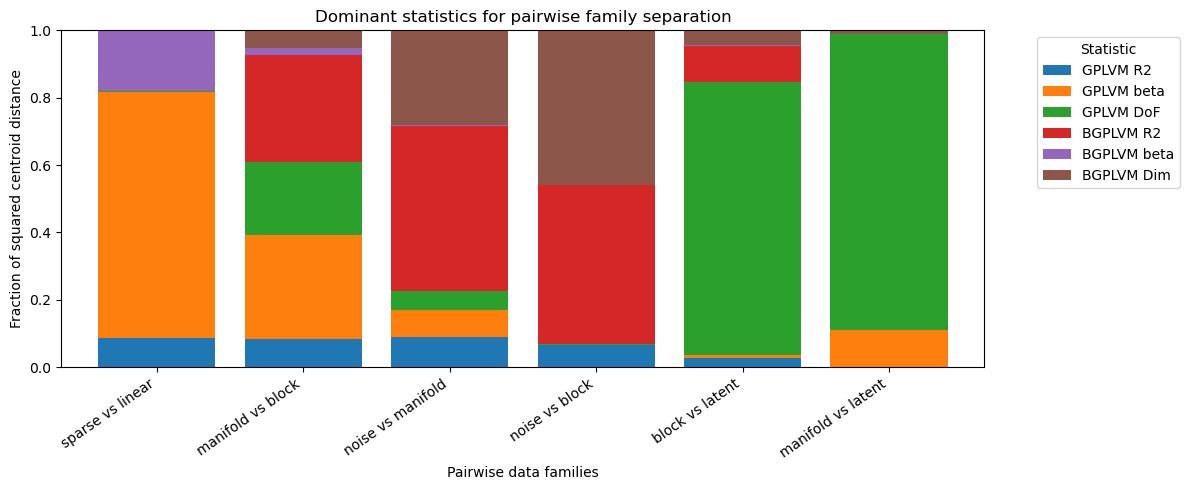

In [135]:
results = results.copy()

if isinstance(results.index, pd.MultiIndex):
    results.index = results.index.get_level_values(0)


X_df = results.groupby(level=0).mean(numeric_only=True)


if isinstance(X_df.columns, pd.MultiIndex):
    X_df.columns = [
        "__".join([str(x) for x in col if str(x) != ""])
        for col in X_df.columns.to_flat_index()
    ]

X_df = X_df.select_dtypes(include=[np.number])

non_constant_cols = X_df.columns[X_df.std(axis=0) > 1e-12]
X_df = X_df[non_constant_cols]


if X_df.shape[1] == 6:
    X_df.columns = [
        "GPLVM R2",
        "GPLVM beta",
        "GPLVM DoF",
        "BGPLVM R2",
        "BGPLVM beta",
        "BGPLVM Dim",
    ]
else:
    print("Warning: X_df does not have exactly 6 columns. Please check columns above.")


X_z = fulcher_sigmoid_normalize(X_df)


def get_family(dataset_name):
    name = str(dataset_name)

    if name in ["Swiss Roll", "S-Curve", "Helicoid", "Sphere", "Intersecting Planes"]:
        return "manifold"
    elif name.startswith("latent"):
        return "latent"
    elif name.startswith("sparse"):
        return "sparse"
    elif name.startswith("linear"):
        return "linear"
    elif name.startswith("block"):
        return "block"
    elif name.startswith("noise"):
        return "noise"
    else:
        return "other"


families = pd.Series(
    [get_family(name) for name in X_z.index],
    index=X_z.index,
    name="family"
)

# compute centroids
centroids = X_z.groupby(families).mean()
family_order = ["manifold", "latent", "sparse", "linear", "block", "noise"]
centroids = centroids.loc[[f for f in family_order if f in centroids.index]]

# compute contributions
def pair_contribution(g1, g2, centroids):
    diff = centroids.loc[g1] - centroids.loc[g2]
    denom = diff.pow(2).sum()

    if denom == 0:
        return diff * np.nan

    contrib = diff.pow(2) / denom
    return contrib


pairs = [
    ("sparse", "linear"),
    ("manifold", "block"),
    ("noise", "manifold"),
    ("noise", "block"),
    ("block", "latent"),
    ("manifold", "latent"),
]


pairs = [(a, b) for a, b in pairs if a in centroids.index and b in centroids.index]

contrib_df = pd.DataFrame({
    f"{a} vs {b}": pair_contribution(a, b, centroids)
    for a, b in pairs
}).T


ax = contrib_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    width=0.8
)

plt.ylabel("Fraction of squared centroid distance")
plt.xlabel("Pairwise data families")
plt.title("Dominant statistics for pairwise family separation")
plt.ylim(0, 1.0)
plt.legend(
    title="Statistic",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("pairwise comparison.pdf", format="pdf", bbox_inches="tight")
plt.show()

These are heatmaps and hierarchical clustering dendrogram between statistics rather than between datasets.

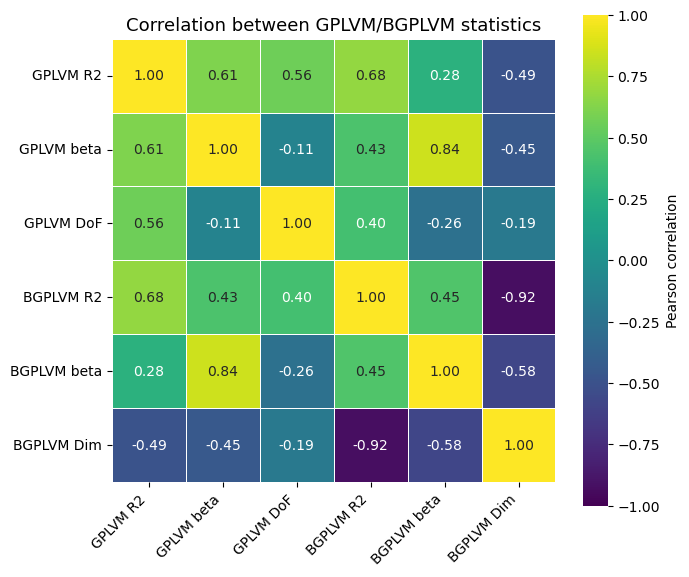

In [136]:
X_fulcher = fulcher_sigmoid_normalize(X_df)


# Correlation between statistics

stat_corr = X_fulcher.corr(method="pearson")



plt.figure(figsize=(7, 6))

sns.heatmap(
    stat_corr,
    cmap="viridis",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Pearson correlation"}
)

plt.title(
    "Correlation between GPLVM/BGPLVM statistics",
    fontsize=13
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "statistics_correlation_heatmap_fulcher.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

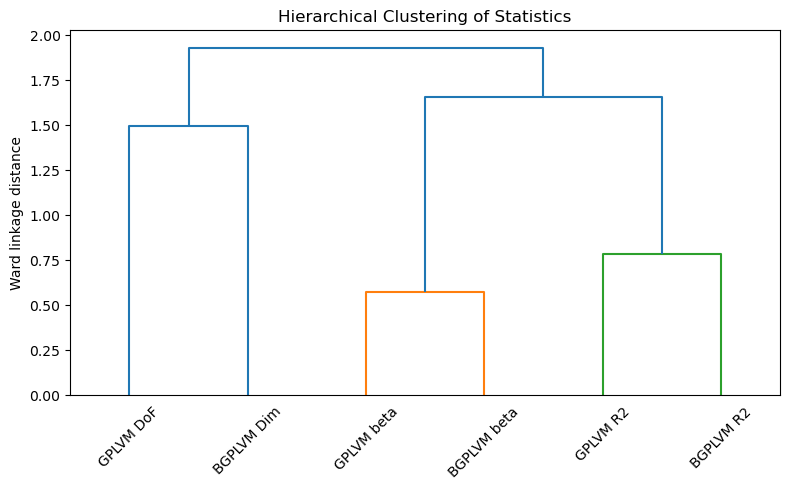

In [137]:
X_fulcher = fulcher_sigmoid_normalize(X_df)

# Transpose: rows = statistics, columns = datasets
D = X_fulcher.T


# Ward clustering between the 6 statistics 
Z_stat = linkage(D.values, method="ward")

# Plot dendrogram
plt.figure(figsize=(8, 5))

dendrogram(
    Z_stat,
    labels=D.index.tolist(),
    leaf_rotation=45,
    leaf_font_size=10,
    color_threshold=None
)

plt.title("Hierarchical Clustering of Statistics")
plt.ylabel("Ward linkage distance")
plt.tight_layout()

plt.savefig(
    "statistics_hierarchical_clustering_fulcher.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

Now we include real-world datasets into the data matrix:

In [32]:
# SP500 stock price datasets
file_path = '/Users/tongxinran/Desktop/SP500/sp500_stocks.csv'
df = pd.read_csv(file_path)
matrix_df = df.pivot(index='Date', columns='Symbol', values='Adj Close')
matrix_df_clean = matrix_df.dropna(axis=1, how='any')
log_returns_df = np.log(matrix_df_clean).diff().dropna()

all_symbols = log_returns_df.columns.tolist()
total_days = len(log_returns_df)

n_required = 1000
p_required = 100
target_count = 10
current_count = 0

finance_datasets = {}

while current_count < target_count:
    sampled_symbols = np.random.choice(all_symbols, size=n_required, replace=(len(all_symbols) < n_required))
    start_idx = np.random.randint(0, total_days)
    
    if start_idx + p_required <= total_days:
        end_idx = start_idx + p_required
        

        log_returns = log_returns_df.iloc[start_idx:end_idx][sampled_symbols].T.to_numpy()
        
        current_count += 1
        finance_datasets[f'finance{current_count}'] = log_returns
    else:
        continue

locals().update(finance_datasets)

In [33]:
# METABRIC breast cancer datasets
file_path = '/Users/tongxinran/Desktop/Breast Cancer/METABRIC_RNA_Mutation.csv'
df = pd.read_csv(file_path, low_memory=False)

df_numeric = df.select_dtypes(include=['float64', 'int64'])

missing_ratio = df_numeric.isnull().mean()
df_final = df_numeric.loc[:, missing_ratio <= 0.2].copy()

col_median = df_final.median(axis=0, skipna=True)
df_final = df_final.fillna(col_median)

df_final = df_final.fillna(0.0)

n_required = 1000 
p_required = 100   
target_count = 10
breast_cancer_dict = {}

all_columns = df_final.columns.to_list()

for i in range(1, target_count + 1):
    sampled_rows = df_final.sample(n=n_required, replace=False)
    sampled_cols = np.random.choice(all_columns, size=p_required, replace=False)
    final_array = sampled_rows[sampled_cols].to_numpy(dtype=np.float64)

    final_array[~np.isfinite(final_array)] = 0.0

    breast_cancer_dict[f'breast{i}'] = final_array

locals().update(breast_cancer_dict)

In [34]:
# Human activity datasets
file_path = '/Users/tongxinran/Desktop/Human Activity/train.csv'
df = pd.read_csv(file_path, low_memory=False)
df = df.select_dtypes(include=['float64', 'int64'])
human_dict = {}

for i in range(1, target_count + 1):
    sampled_rows = df.sample(n=n_required)
    
    all_columns = sampled_rows.columns.tolist()
    sampled_cols = np.random.choice(all_columns, size=p_required, replace=False)

    final_array = sampled_rows[sampled_cols].to_numpy()
    

    dataset_name = f'human{i}'
    human_dict[dataset_name] = final_array
    

locals().update(human_dict)

In [35]:
def zscore_columns(X: np.ndarray, eps: float = 1e-9) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64)
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    sd = np.where(sd < eps, 1.0, sd)
    return (X - mu) / sd


def run_all_and_store_results(datasets: dict, cfg, do_zscore=False):
    all_results = {}
    names = sorted(datasets.keys())

    for i, name in enumerate(names, 1):
        X = datasets[name]
        if do_zscore:
            X = zscore_columns(X)

        calc = Calculator(X)
        calc.compute(cfg)
        all_results[name] = calc.results  

        print(f"[{i:02d}/{len(names)}] done: {name}")

    return all_results


# combine all real-world datasets together
datasets_empirical = {}
datasets_empirical.update(finance_datasets)        # finance1 to finance10
datasets_empirical.update(breast_cancer_dict)      # breast1 to breast10
datasets_empirical.update(human_dict)              # human1 to human10

# run py-spoc
all_results_empirical = run_all_and_store_results(datasets_empirical, cfg, do_zscore=True)

# py-spoc data matrix
df_all_empirical = pd.concat(all_results_empirical)
print("df_all_empirical shape:", df_all_empirical.shape)

Normalising the dataset using StandardScaler 



Processing [None: GPLVM_R2.py.GPLVM_r2.scheme_1]:   0%|   | 0/6 [00:00<?, ?it/s]

DEBUG: Starting optimization. Data shape: (1000, 100)


Processing [None: GPLVM_Beta.py.GPLVM_beta.scheme_1]:  17%|▏| 1/6 [00:22<01:51, 

DEBUG: Opt result: STOP: TOTAL NO. of ITERATIONS REACHED LIMIT, Iters: 200, Loss: 117400.1385
DEBUG: Raw Diff: 78824.90, Scaled Diff (by N): 0.79
DEBUG: Starting optimization for Beta. Data shape: (1000, 100)


...

DEBUG: Opt result: STOP: TOTAL NO. of ITERATIONS REACHED LIMIT, Loss: 47885.3728
DEBUG: Estimated DoF: 705.2130 (Normalized: 0.7052)
DEBUG: Starting GPyTorch training. Data: (1000, 100)


Processing [None: GPyTorch_BayesianGPLVM_Beta.py.GPyTorch_BayesianGPLVM_Beta.sch

DEBUG: ELL_real: -48845.17, ELL_null: -944387.50
DEBUG: Real Noise Variance: 0.016142 (Beta: 61.95)
DEBUG: GPyTorch Pseudo R2: 0.948278


Processing [None: GPyTorch_BayesianGPLVM_Dim3.py.GPyTorch_BayesianGPLVM_Dim3.sch

DEBUG: Mean Lengthscales: [4.09 5.47 6.07 5.79 6.2  5.92 6.02 5.99 5.99 6.01]
DEBUG: Latent Std: [1.836 0.5   0.474 0.043 0.327 0.065 0.115 0.025 0.03  0.048]
DEBUG: Contribution Ratio: [0.619 0.126 0.108 0.01  0.073 0.015 0.026 0.006 0.007 0.011]
DEBUG: Sorted Cumulative Ratios: [0.619 0.744 0.852 0.925 0.951 0.966 0.977 0.987 0.994 1.   ]
DEBUG: Active Dimensions (Count): 4

Calculation complete. Time taken: 166.6014s
[30/30] done: human9
df_all_empirical shape: (30, 6)


In [109]:
df_all_empirical

,Statistic,GPLVM_R2.py.GPLVM_r2.scheme_1,GPLVM_Beta.py.GPLVM_beta.scheme_1,GPLVM_DoF.py.GPLVM_dof.scheme_1,GPyTorch_BayesianGPLVM_R2.py.GPyTorch_BayesianGPLVM_R2.scheme_1,GPyTorch_BayesianGPLVM_Beta.py.GPyTorch_BayesianGPLVM_Beta.scheme_1,GPyTorch_BayesianGPLVM_Dim3.py.GPyTorch_BayesianGPLVM_Dim3.scheme_1
,Reducer,self,self,self,self,self,self
breast1,0,0.401707,4.530905e+00,415.447778,0.484591,7.620319,4.0
breast10,0,0.167980,1.767715e+00,11.175790,0.400702,5.390753,5.0
breast2,0,0.217389,1.935665e+00,29.008308,0.405468,5.008769,5.0
breast3,0,0.379123,1.844542e+00,383.201022,0.432184,6.281789,5.0
breast4,0,0.195272,1.861518e+00,11.238662,0.453758,6.215259,2.0
breast5,0,0.204522,1.852830e+00,11.286075,0.429619,4.434356,4.0
breast6,0,0.357692,1.696879e+00,363.463434,0.388368,5.976919,5.0
breast7,0,0.215091,1.399506e+00,10.813800,0.440263,5.991069,5.0
breast8,0,0.180349,1.834704e+00,11.196851,0.406099,4.437910,4.0


In [138]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list, fcluster


def results_to_matrix(results_obj):
    """
    Convert py-spoc concatenated results into a dataset x statistic matrix.
    Rows = datasets
    Columns = statistics
    """
    df = results_obj.copy()


    if isinstance(df.index, pd.MultiIndex):
        df.index = df.index.get_level_values(0)


    X = df.groupby(level=0).mean(numeric_only=True)


    if isinstance(X.columns, pd.MultiIndex):
        X.columns = [
            "__".join([str(x) for x in col if str(x) != ""])
            for col in X.columns.to_flat_index()
        ]


    X = X.select_dtypes(include=[np.number])

    return X



X_synthetic = results_to_matrix(results)
X_empirical = results_to_matrix(df_all_empirical)


X_synthetic.index = [f"syn_{idx}" for idx in X_synthetic.index]
X_empirical.index = [f"emp_{idx}" for idx in X_empirical.index]

print("Synthetic matrix shape:", X_synthetic.shape)
print("Empirical matrix shape:", X_empirical.shape)


common_cols = X_synthetic.columns.intersection(X_empirical.columns)

X_synthetic = X_synthetic[common_cols]
X_empirical = X_empirical[common_cols]

X_all = pd.concat([X_synthetic, X_empirical], axis=0)


non_constant_cols = X_all.columns[X_all.std(axis=0) > 1e-12]
X_all = X_all[non_constant_cols]


if X_all.shape[1] == 6:
    X_all.columns = [
        "GPLVM R2",
        "GPLVM beta",
        "GPLVM DoF",
        "BGPLVM R2",
        "BGPLVM beta",
        "BGPLVM Dim",
    ]

print("Combined data matrix shape:", X_all.shape)


X_clean = X_all.replace([np.inf, -np.inf], np.nan)
X_clean = X_clean.fillna(X_clean.median(axis=0))

Synthetic matrix shape: (30, 6)
Empirical matrix shape: (30, 6)
Combined data matrix shape: (60, 6)


### This is the (60, 6) py-spoc data matrix

In [139]:
X_all

,GPLVM R2,GPLVM beta,GPLVM DoF,BGPLVM R2,BGPLVM beta,BGPLVM Dim
syn_Helicoid,1.006077,1.219452e+02,10.802928,1.010091,235.662725,2.0
syn_Intersecting Planes,1.015113,1.174785e+02,18.264884,1.010392,177.722907,3.0
syn_S-Curve,1.012815,1.174129e+02,20.945148,1.009792,199.342776,3.0
syn_Sphere,1.013525,1.145476e+02,19.526130,1.010449,199.650977,3.0
syn_Swiss Roll,1.014689,1.157342e+02,18.746942,1.009962,251.101452,3.0
syn_block_1,0.575621,3.959511e+00,11.418032,0.749920,6.663947,2.0
syn_block_2,0.569157,3.860220e+00,11.289557,0.750735,6.636018,3.0
syn_block_3,0.577572,3.931008e+00,11.362940,0.749792,6.637968,4.0
syn_block_4,0.578775,3.896682e+00,11.470878,0.746519,6.495257,5.0
syn_block_5,0.531414,3.729664e+00,11.226195,0.743449,6.501143,6.0


In [140]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


X_fulcher = fulcher_sigmoid_normalize(X_clean)

X_scaled_df = pd.DataFrame(
    X_fulcher.values,
    index=X_clean.index,
    columns=X_clean.columns
)

print("Fulcher-normalised matrix shape:", X_scaled_df.shape)


# hierarchical clustering on datasets

Z = linkage(X_scaled_df.values, method="ward")

# 9 clusters

k = 9

clusters = fcluster(
    Z,
    t=k,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "dataset": X_scaled_df.index,
    "cluster": clusters
}).sort_values(["cluster", "dataset"])



def get_true_family(dataset_name):
    """
    Map each dataset name to its true dataset family.
    Assumes names are prefixed by syn_ or emp_.
    """
    name = str(dataset_name)

    # Remove prefix
    if name.startswith("syn_"):
        name0 = name.replace("syn_", "", 1)
    elif name.startswith("emp_"):
        name0 = name.replace("emp_", "", 1)
    else:
        name0 = name

    # Synthetic dataset families
    if name0 in ["Swiss Roll", "S-Curve", "Helicoid", "Sphere", "Intersecting Planes"]:
        return "manifold"
    elif name0.startswith("latent"):
        return "latent"
    elif name0.startswith("sparse"):
        return "sparse"
    elif name0.startswith("linear"):
        return "linear"
    elif name0.startswith("block"):
        return "block"
    elif name0.startswith("noise"):
        return "noise"

    # Empirical dataset families
    elif name0.startswith("finance"):
        return "finance"
    elif name0.startswith("breast"):
        return "breast"
    elif name0.startswith("human"):
        return "human"

    else:
        return "other"


cluster_eval_df = cluster_df.copy()
cluster_eval_df["true_family"] = cluster_eval_df["dataset"].map(get_true_family)





# Compute ARI, NMI

y_true = cluster_eval_df["true_family"].values
y_pred = cluster_eval_df["cluster"].values

ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)


print("\nClustering evaluation metrics with Fulcher-style normalisation:")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")


Fulcher-normalised matrix shape: (60, 6)

Clustering evaluation metrics with Fulcher-style normalisation:
Adjusted Rand Index (ARI): 0.8369
Normalized Mutual Information (NMI): 0.9273


Fulcher-normalised matrix shape: (60, 6)


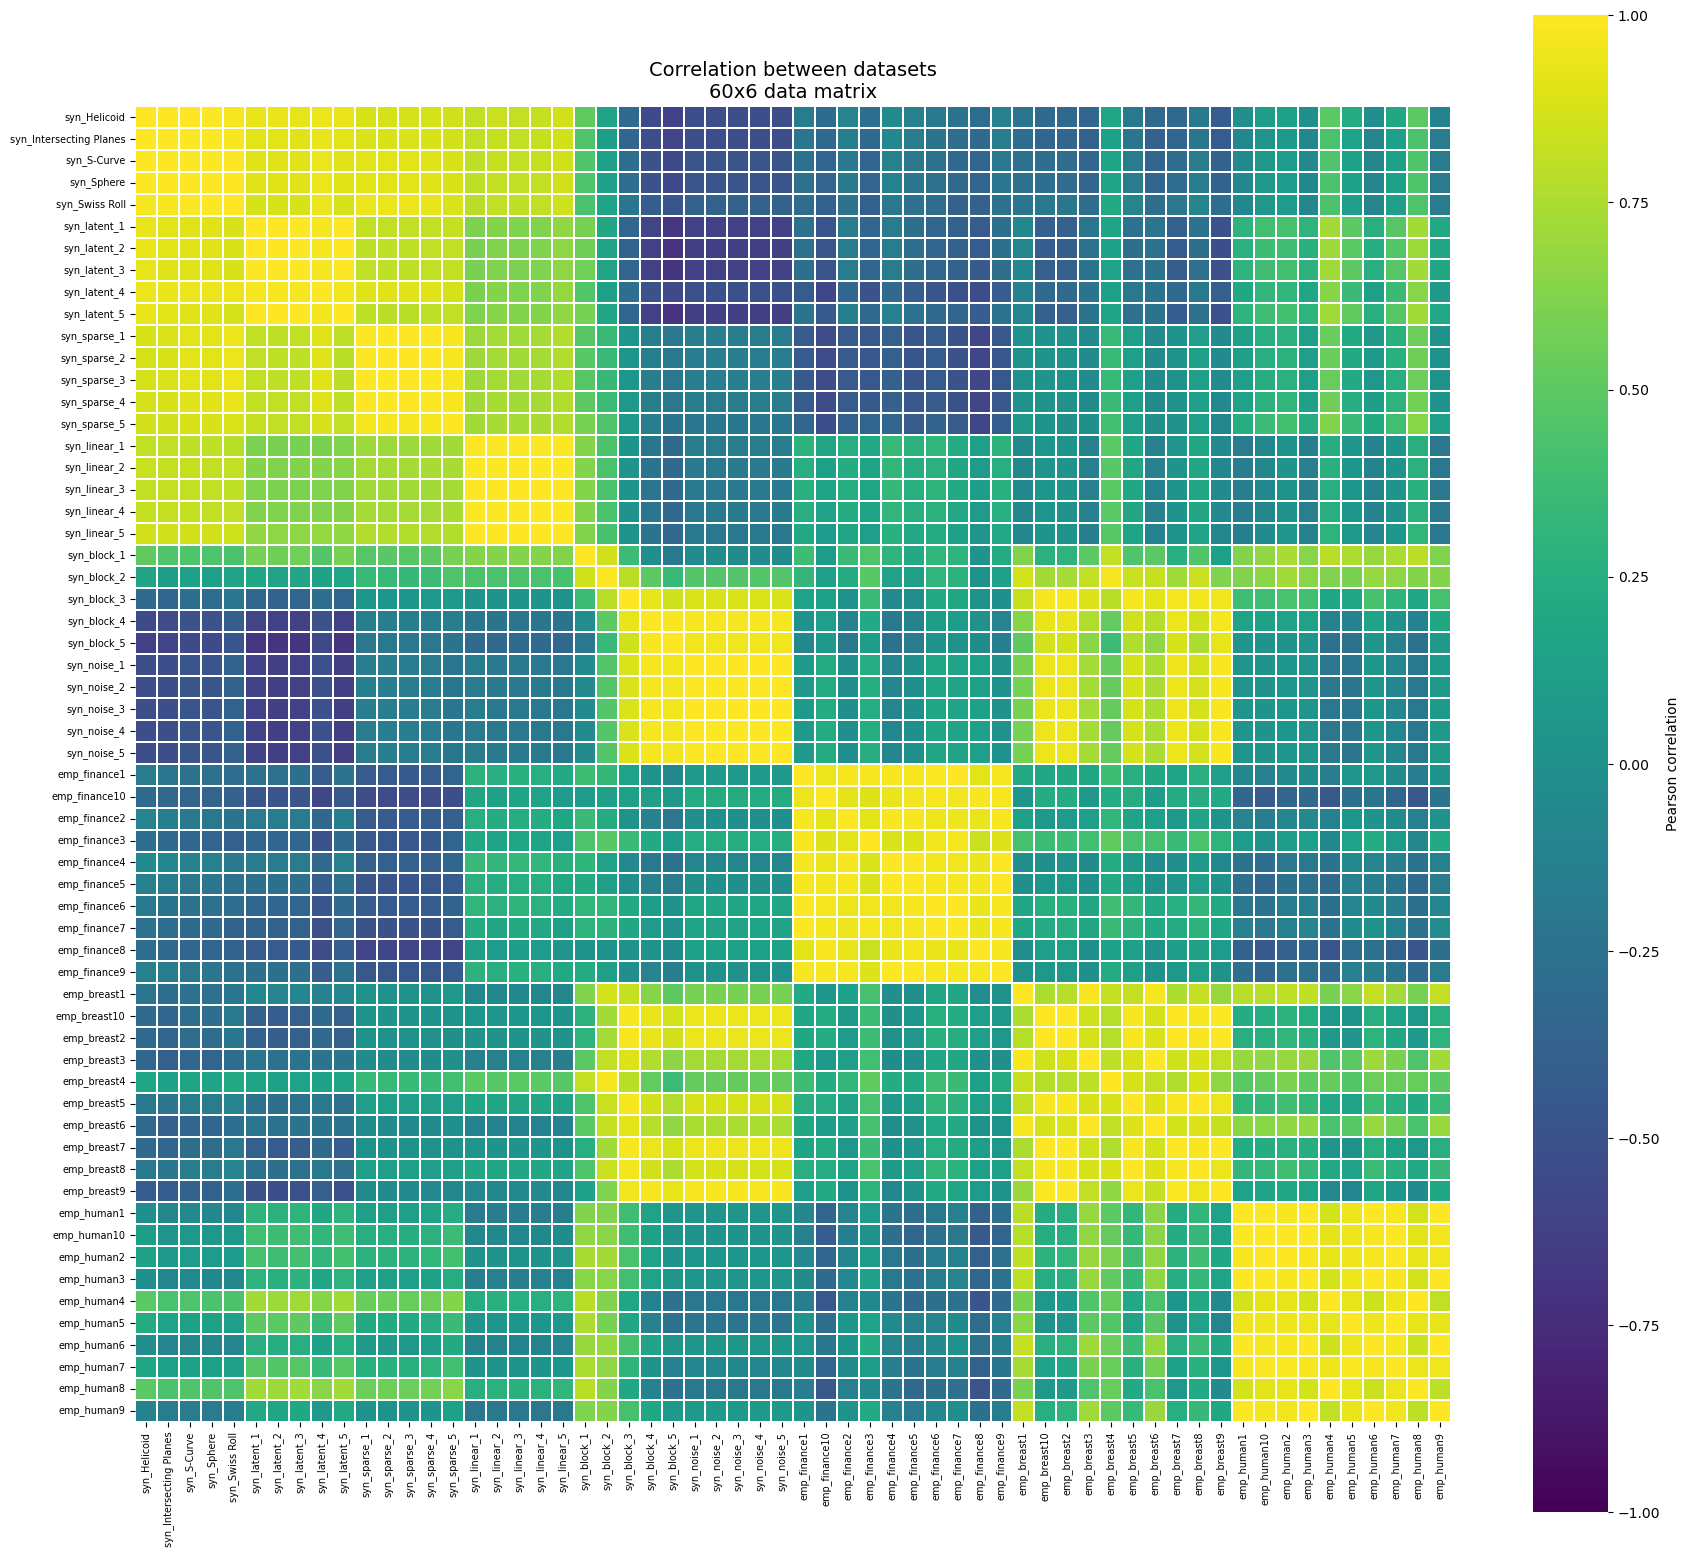

In [142]:
X_fulcher = fulcher_sigmoid_normalize(X_clean)

X_fulcher_df = pd.DataFrame(
    X_fulcher.values,
    index=X_clean.index,
    columns=X_clean.columns
)

print("Fulcher-normalised matrix shape:", X_fulcher_df.shape)


family_series = pd.Series(
    [get_true_family(idx) for idx in X_fulcher_df.index],
    index=X_fulcher_df.index,
    name="family"
)

family_order = [
    "manifold",
    "latent",
    "sparse",
    "linear",
    "block",
    "noise",
    "finance",
    "breast",
    "human",
]

order_df = pd.DataFrame({
    "dataset": X_fulcher_df.index,
    "family": family_series.loc[X_fulcher_df.index].values
})

order_df["family"] = pd.Categorical(
    order_df["family"],
    categories=family_order,
    ordered=True
)

order_df = order_df.sort_values(["family", "dataset"])
ordered_datasets = order_df["dataset"].tolist()



dataset_corr = X_fulcher_df.T.corr(method="pearson")
dataset_corr_ordered = dataset_corr.loc[ordered_datasets, ordered_datasets]


plt.figure(figsize=(18, 16))

sns.heatmap(
    dataset_corr_ordered,
    cmap="viridis",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.12,
    linecolor="white",
    cbar_kws={"label": "Pearson correlation"}
)

plt.title(
    "Correlation between datasets\n"
    "60x6 data matrix",
    fontsize=14
)

plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()

plt.savefig(
    "dataset_correlation_heatmap_60x6_fulcher.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

Now we do a final experiment, we include other existing py-spoc statistics into the data matrix:

In [120]:
# combine synthetic datasets and real-world datasets
datasets_combined = {}

for name, X in all_datasets_30.items():
    datasets_combined[f"syn_{name}"] = X

for name, X in datasets_empirical.items():
    datasets_combined[f"emp_{name}"] = X

print("Total number of datasets:", len(datasets_combined))

for name, X in datasets_combined.items():
    print(name, X.shape)



# put into py-spoc framework

all_results_combined = {}

for i, (name, X) in enumerate(datasets_combined.items(), start=1):

    print(f"\n[{i:02d}/{len(datasets_combined)}] Computing: {name}, shape={X.shape}")

    cfg = Config.from_yaml_file("mega_yaml", "mega_yaml.yml")

    calc = Calculator(X)
    calc.compute(cfg)

    results = calc.results

    all_results_combined[name] = results

    print(f"Done: {name}")




results_combined = pd.concat(all_results_combined)

print("Combined results shape:", results_combined.shape)
results_combined

Total number of datasets: 60
syn_Swiss Roll (1000, 100)
syn_S-Curve (1000, 100)
syn_Helicoid (1000, 100)
syn_Sphere (1000, 100)
syn_Intersecting Planes (1000, 100)
syn_latent_1 (1000, 100)
syn_latent_2 (1000, 100)
syn_latent_3 (1000, 100)
syn_latent_4 (1000, 100)
syn_latent_5 (1000, 100)
syn_sparse_1 (1000, 100)
syn_sparse_2 (1000, 100)
syn_sparse_3 (1000, 100)
syn_sparse_4 (1000, 100)
syn_sparse_5 (1000, 100)
syn_linear_1 (1000, 100)
syn_linear_2 (1000, 100)
syn_linear_3 (1000, 100)
syn_linear_4 (1000, 100)
syn_linear_5 (1000, 100)
syn_block_1 (1000, 100)
syn_block_2 (1000, 100)
syn_block_3 (1000, 100)
syn_block_4 (1000, 100)
syn_block_5 (1000, 100)
syn_noise_1 (1000, 100)
syn_noise_2 (1000, 100)
syn_noise_3 (1000, 100)
syn_noise_4 (1000, 100)
syn_noise_5 (1000, 100)
emp_finance1 (1000, 100)
emp_finance2 (1000, 100)
emp_finance3 (1000, 100)
emp_finance4 (1000, 100)
emp_finance5 (1000, 100)
emp_finance6 (1000, 100)
emp_finance7 (1000, 100)
emp_finance8 (1000, 100)
emp_finance9 (1000, 1

Processing [None: pyspoc.statistics.basic.Covariance.empirical]: 100%|█| 1/1 [00
Processing [None: /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/sum
Processing [None: /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/sum











Calculation complete. Time taken: 0.7047s
Done: syn_Swiss Roll

[02/60] Computing: syn_S-Curve, shape=(1000, 100)
Registering YAML configuration file: mega_yaml.yml.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'empirical' added successfully.
  ✔ Module /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py already loaded.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'cosine_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'euclidean_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'canberra_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'cosine_skew_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'euclidean_skew_meance

Processing [None: pyspoc.statistics.basic.Covariance.empirical]: 100%|█| 1/1 [00
Processing [None: /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/sum
Processing [None: /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/sum











Calculation complete. Time taken: 0.4576s
Done: syn_S-Curve

[03/60] Computing: syn_Helicoid, shape=(1000, 100)
Registering YAML configuration file: mega_yaml.yml.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'empirical' added successfully.
  ✔ Module /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py already loaded.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'cosine_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'euclidean_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'canberra_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'cosine_skew_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'euclidean_skew_meancent

...

Processing [None: pyspoc.statistics.basic.Covariance.empirical]: 100%|█| 1/1 [00
Processing [None: /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/sum
Processing [None: /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/sum











Calculation complete. Time taken: 1.2844s
Done: emp_human9

[60/60] Computing: emp_human10, shape=(1000, 100)
Registering YAML configuration file: mega_yaml.yml.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'empirical' added successfully.
  ✔ Module /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py already loaded.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'cosine_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'euclidean_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'canberra_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'cosine_skew_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'euclidean_skew_meancentro

Processing [None: pyspoc.statistics.basic.Covariance.empirical]: 100%|█| 1/1 [00
Processing [None: /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/sum
Processing [None: /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/sum











Calculation complete. Time taken: 0.4595s
Done: emp_human10
Combined results shape: (60, 22)


Statistic                                                                                                           pyspoc.statistics.basic.Covariance.empirical  \
Reducer                   /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/feature_covariance_stats.py.MaxCovPerFeature.max_min_median_1   
syn_Swiss Roll          0                                 0.990472+0.000000j                                                                                       
syn_S-Curve             0                                 0.990858+0.000000j                                                                                       
syn_Helicoid            0                                 0.990869+0.000000j                                                                                       
syn_Sphere              0                                 0.990561+0.000000j                                                                                       
syn_Intersecting Planes 0                                 0.989970+0.000000j                                                                                       
syn_latent_1            0                                 0.984721+0.000000j                                                                                       
syn_latent_2            0                                 0.983628+0.000000j                                                                                       
syn_latent_3            0                                 0.984910+0.000000j                                                                                       
syn_latent_4            0                                 0.981904+0.000000j                                                                                       
syn_latent_5            0                                 0.984412+0.000000j                                                                                       
syn_sparse_1            0                                 0.999970+0.000000j                                                                                       
syn_sparse_2            0                                 0.999977+0.000000j                                                                                       
syn_sparse_3            0                                 0.999975+0.000000j                                                                                       
syn_sparse_4            0                                 0.999980+0.000000j                                                                                       
syn_sparse_5            0                                 0.999968+0.000000j                                                                                       
syn_linear_1            0                                 0.999985+0.000000j                                                                                       
syn_linear_2            0                                 0.999989+0.000000j                                                                                       
syn_linear_3            0                                 0.999989+0.000000j                                                                                       
syn_linear_4            0                                 0.999989+0.000000j                                                                                       
syn_linear_5            0                                 0.999980+0.000000j                                                                                       
syn_block_1             0                                 0.759759+0.000000j                                                                                       
syn_block_2             0                                 0.754139+0.000000j                                                                                       
syn_block_3             0                                 0.7483

In [144]:
def clean_feature_matrix(df, prefix=None):
    """
    Convert a dataframe into dataset x feature matrix.

    If index is MultiIndex, use the first level as dataset name and average.
    If columns are MultiIndex, flatten them.
    Keep numeric columns only.
    """
    X = df.copy()

    if isinstance(X.index, pd.MultiIndex):
        X.index = X.index.get_level_values(0)
        X = X.groupby(level=0).mean(numeric_only=True)

    if isinstance(X.columns, pd.MultiIndex):
        X.columns = [
            "__".join([str(x) for x in col if str(x) != ""])
            for col in X.columns.to_flat_index()
        ]

    X = X.select_dtypes(include=[np.number])

    if prefix is not None:
        X.columns = [f"{prefix}_{col}" for col in X.columns]

    return X



X_22 = clean_feature_matrix(results_combined, prefix="extra")
X_6 = clean_feature_matrix(X_all, prefix="sixstat")

print("X_22 shape:", X_22.shape)
print("X_6 shape:", X_6.shape)



common_index = X_22.index.intersection(X_6.index)

X_22 = X_22.loc[common_index]
X_6 = X_6.loc[common_index]

X_28 = pd.concat([X_22, X_6], axis=1)


print("Final matrix used for heatmap/clustering:", X_28.shape)



X_clean = X_28.copy()
X_array = X_clean.to_numpy()

# if complex dtype exist but with 0.j，taking the real part
if np.iscomplexobj(X_array):
    max_imag = np.nanmax(np.abs(np.imag(X_array)))
    print(f"Maximum absolute imaginary part: {max_imag:.3e}")

    if max_imag < 1e-10:
        X_clean = pd.DataFrame(
            np.real(X_array),
            index=X_clean.index,
            columns=X_clean.columns
        )
    else:
        complex_cols = [
            col for col in X_clean.columns
            if np.iscomplexobj(X_clean[col].to_numpy())
        ]
        raise ValueError(
            "Some statistics contain non-negligible complex values. "
            f"Please inspect these columns: {complex_cols}"
        )

X_clean = X_clean.replace([np.inf, -np.inf], np.nan)
X_clean = X_clean.fillna(X_clean.median(axis=0))
X_clean = X_clean.astype(float)

X_22 shape: (60, 22)
X_6 shape: (60, 6)
Final matrix used for heatmap/clustering: (60, 28)
Maximum absolute imaginary part: 0.000e+00


### This is the (60, 28) py-spoc data matrix

In [145]:
X_clean

,extra_pyspoc.statistics.basic.Covariance.empirical__/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/feature_covariance_stats.py.MaxCovPerFeature.max_min_median_1,extra_pyspoc.statistics.basic.Covariance.empirical__/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/feature_covariance_stats.py.MaxCovPerFeature.max_min_median_2,extra_pyspoc.statistics.basic.Covariance.empirical__/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/feature_covariance_stats.py.MaxCovPerFeature.max_min_median_3,extra_pyspoc.statistics.basic.Covariance.empirical__/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/feature_covariance_stats.py.EigenAMGMRatio.eigen_amgm,extra_pyspoc.statistics.basic.Covariance.empirical__/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/feature_covariance_stats.py.EigenEntropy.eigen_entropy,extra_/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionBasicSummarize.cosine_distrib_meancentroid__self_1,extra_/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionBasicSummarize.cosine_distrib_meancentroid__self_2,extra_/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionBasicSummarize.cosine_distrib_meancentroid__self_3,extra_/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionBasicSummarize.euclidean_distrib_meancentroid__self_1,extra_/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionBasicSummarize.euclidean_distrib_meancentroid__self_2,...,extra_/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionBasicSummarize.euclidean_kurt_meancentroid__self,extra_/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionModesSummarize.corr_peaks_meancentroid__self,extra_/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionModesSummarize.euclidean_peaks_meancentroid__self,extra_/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionModesSummarize.canberra_peaks_meancentroid__self,sixstat_GPLVM R2,sixstat_GPLVM beta,sixstat_GPLVM DoF,sixstat_BGPLVM R2,sixstat_BGPLVM beta,sixstat_BGPLVM Dim
emp_breast1,0.831907,0.084745,0.353495,1.560281,4.093598,0.095971,1.000514,0.121726,2.164613,9.762912,...,4.580052,4.0,3.0,3.0,0.401707,4.530905e+00,415.447778,0.484591,7.620319,4.0
emp_breast10,0.671409,0.083949,0.335466,1.459585,4.162959,0.109979,1.000312,0.148964,2.157145,9.764565,...,4.763123,1.0,4.0,1.0,0.167980,1.767715e+00,11.175790,0.400702,5.390753,5.0
emp_breast2,0.838372,0.094546,0.391845,1.495755,4.141407,0.098648,0.998848,0.140548,2.002463,9.797456,...,1.936533,1.0,2.0,5.0,0.217389,1.935665e+00,29.008308,0.405468,5.008769,5.0
emp_breast3,0.665220,0.081751,0.360543,1.497640,4.130045,0.112496,0.995977,0.148791,2.010489,9.795812,...,4.042596,1.0,2.0,6.0,0.379123,1.844542e+00,383.201022,0.432184,6.281789,5.0
emp_breast4,0.719103,0.074721,0.395903,1.590069,4.045262,0.111976,0.996862,0.161395,2.081856,9.780893,...,3.291066,1.0,3.0,4.0,0.195272,1.861518e+00,11.238662,0.453758,6.215259,2.0
emp_breast5,0.595855,0.093819,0.368076,1.519396,4.119224,0.102097,1.001685,0.146406,2.147558,9.766678,...,3.271900,1.0,2.0,3.0,0.204522,1.852830e+00,11.286075,0.429619,4.434356,4.0
emp_breast6,0.647401,0.081619,0.334492,1.454539,4.180435,0.088700,1.001645,0.117443,1.902783,9.817302,...,2.704317,1.0,1.0,3.0,0.357692,1.696879e+00,363.463434,0.388368,5.976919,5.0
emp_breast7,0.692811,0.079500,0.378490,1.554337,4.095212,0.097532,1.002535,0.131170,1.911893,9.815532,...,2.327781

Fulcher-normalised matrix shape: (60, 28)


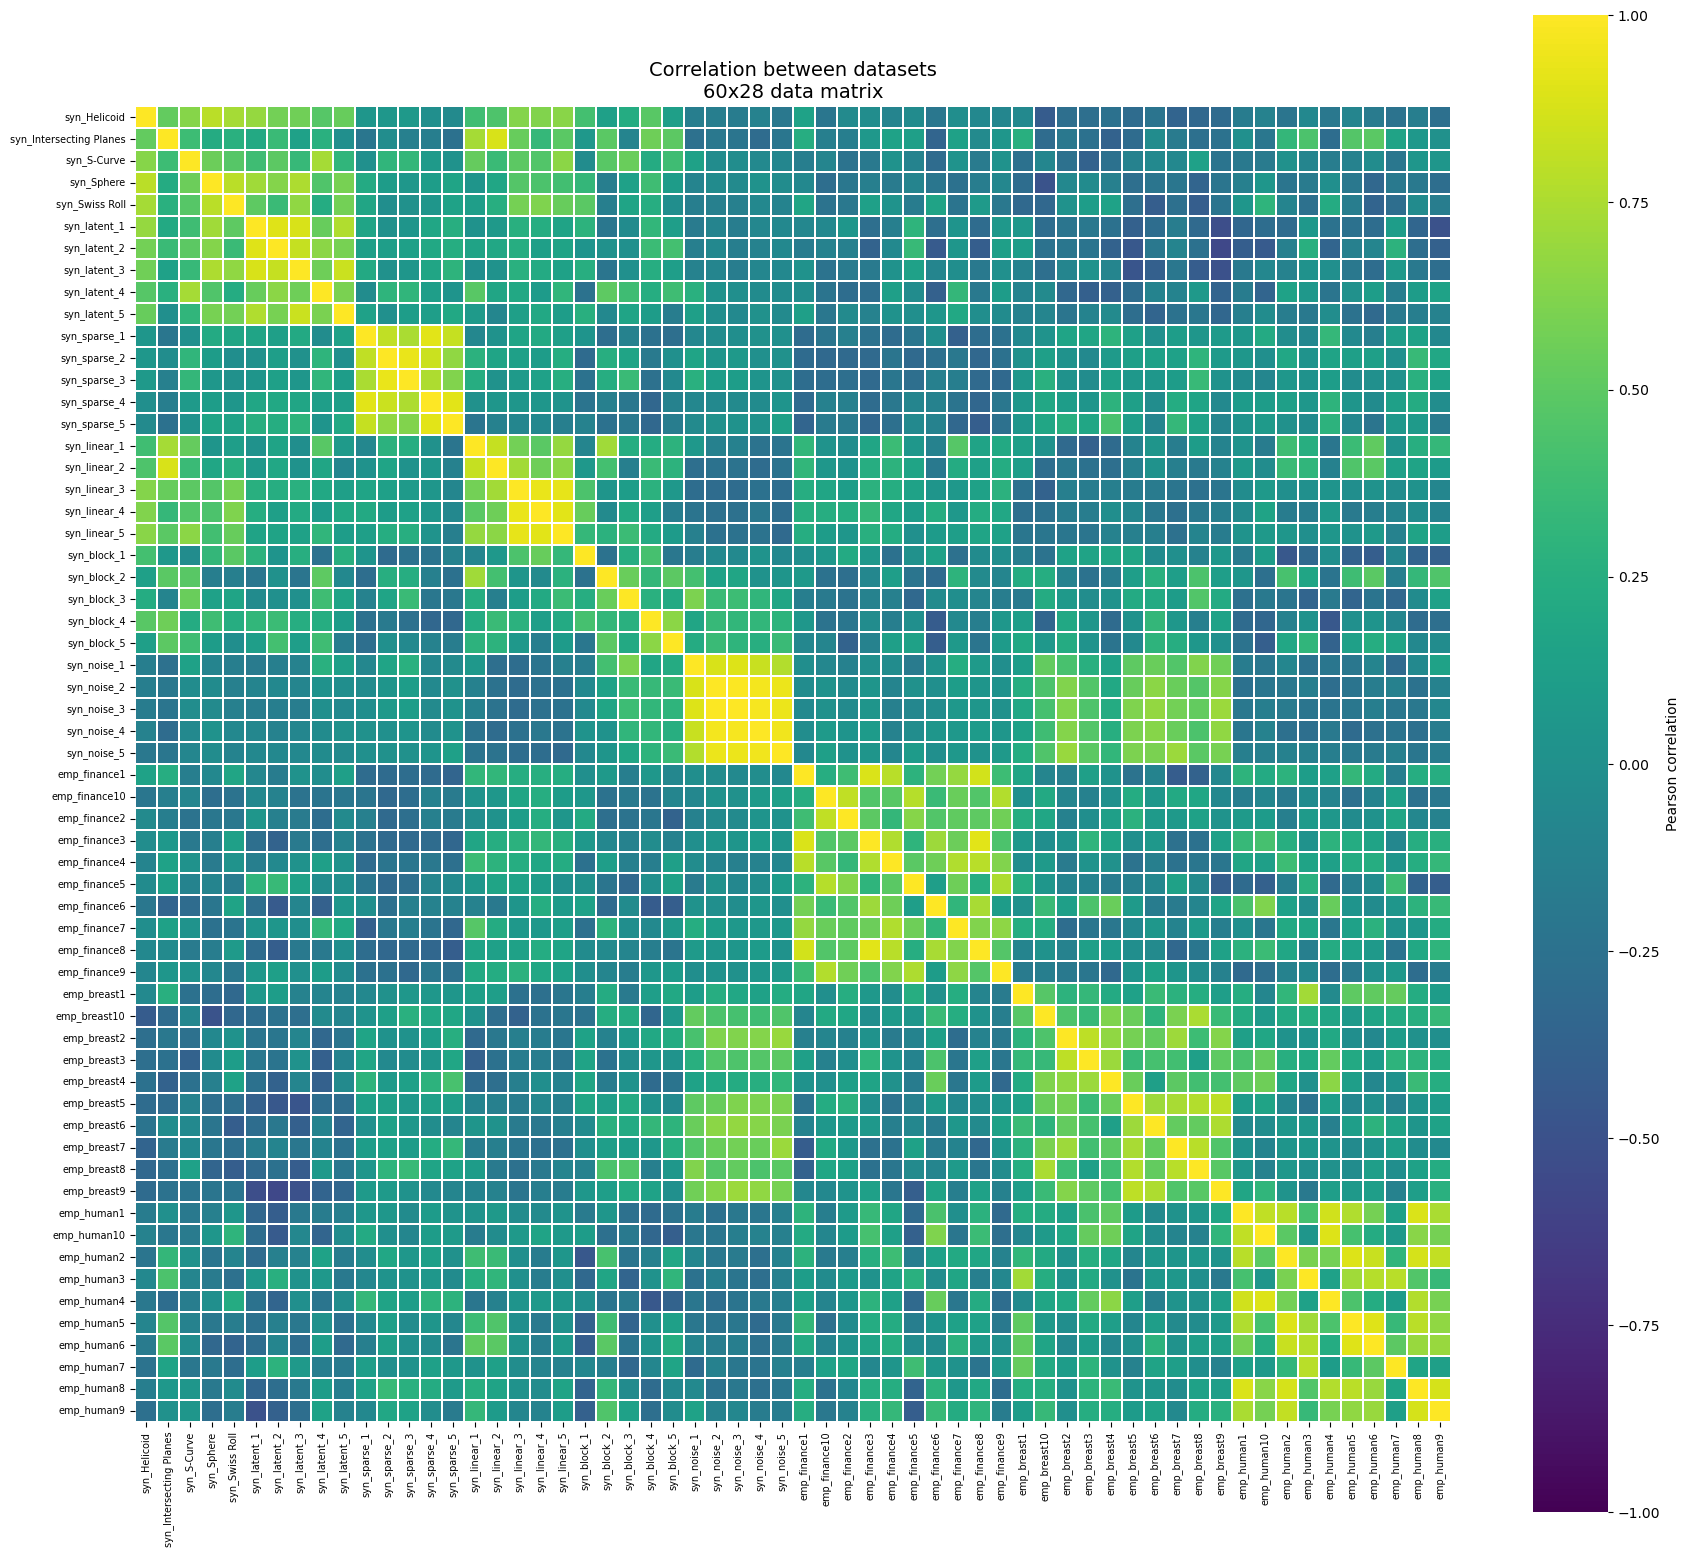

In [146]:
X_fulcher_df = fulcher_sigmoid_normalize(X_clean)

print("Fulcher-normalised matrix shape:", X_fulcher_df.shape)



dataset_corr = X_fulcher_df.T.corr(method="pearson")




family_order = [
    "manifold",
    "latent",
    "sparse",
    "linear",
    "block",
    "noise",
    "finance",
    "breast",
    "human",
]

order_df = pd.DataFrame({
    "dataset": X_fulcher_df.index,
    "family": family_series.loc[X_fulcher_df.index].values
})

order_df["family"] = pd.Categorical(
    order_df["family"],
    categories=family_order,
    ordered=True
)

order_df = order_df.sort_values(["family", "dataset"])
ordered_datasets = order_df["dataset"].tolist()

dataset_corr_grouped = dataset_corr.loc[ordered_datasets, ordered_datasets]


plt.figure(figsize=(18, 16))

ax = sns.heatmap(
    dataset_corr_grouped,
    cmap="viridis",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.10,
    linecolor="white",
    cbar_kws={"label": "Pearson correlation"}
)

plt.title(
    "Correlation between datasets\n"
    "60x28 data matrix",
    fontsize=14
)

plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()

plt.savefig(
    "dataset_correlation_heatmap_60x28_fulcher.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [148]:
Z = linkage(X_fulcher_df.values, method="ward")

k = 9

clusters = fcluster(
    Z,
    t=k,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "dataset": X_fulcher_df.index.astype(str),
    "cluster": clusters
}).sort_values(["cluster", "dataset"])


def get_true_family_robust(dataset_name):
    name = str(dataset_name)

    # remove common prefixes
    if name.startswith("syn_"):
        name0 = name.replace("syn_", "", 1)
    elif name.startswith("emp_"):
        name0 = name.replace("emp_", "", 1)
    else:
        name0 = name

    # lower-case version for robust matching
    low = name0.lower().strip()

    # synthetic manifold datasets
    manifold_names = {
        "swiss roll",
        "s-curve",
        "helicoid",
        "sphere",
        "intersecting planes"
    }

    if low in manifold_names:
        return "manifold"

    # synthetic families
    if low.startswith("latent"):
        return "latent"
    if low.startswith("sparse"):
        return "sparse"
    if low.startswith("linear"):
        return "linear"
    if low.startswith("block"):
        return "block"
    if low.startswith("noise"):
        return "noise"

    # empirical families
    if low.startswith("finance"):
        return "finance"
    if low.startswith("breast"):
        return "breast"
    if low.startswith("human"):
        return "human"

    return "other"


cluster_df["true_family"] = cluster_df["dataset"].map(get_true_family_robust)


unmatched = cluster_df.loc[cluster_df["true_family"] == "other", "dataset"].tolist()
if len(unmatched) > 0:
    print("\nUnmatched dataset names:")
    print(unmatched[:30])


if cluster_df["true_family"].nunique() <= 1:
    raise ValueError(
        "All datasets were mapped to the same true_family. "
        "Please inspect X_fulcher_df.index and update get_true_family_robust()."
    )




# compute ARI, NMI

y_true = cluster_df["true_family"].values
y_pred = cluster_df["cluster"].values

ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)

print("\nClustering evaluation metrics:")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")



Clustering evaluation metrics:
Adjusted Rand Index (ARI): 0.6627
Normalized Mutual Information (NMI): 0.8235
